In [5]:
# !pip install langgraph langchain_openai langchain_groq

In [6]:
# !pip install -U "langchain[openai]"
# !pip install -U "langchain[google-genai]"

In [26]:
from langgraph.graph import StateGraph, START, END
# from langchain_openai import init_chat_model
# from langchain_groq import ChatGroq
from langchain_openai import ChatOpenAI
# from langchain_openai import ChatOpenAI
# from langchain_openai import ChatOpenAI
# from typing import TypedDict
# from langchain_groq import ChatGroq
from dotenv import load_dotenv
import os

In [34]:
from langchain_groq import ChatGroq

# model = ChatGroq(
#     model="qwen/qwen3-32b",
#     temperature=0,
#     max_tokens=None,
#     reasoning_format="parsed",
#     timeout=None,
#     max_retries=2,
#     api_key=os.getenv("GROK_API_KEY")
# )
model = ChatOpenAI(temperature=0)

In [35]:
load_dotenv()

True

In [36]:
# os.environ['OPENAI_API_KEY'] = "API_KEY"

In [37]:
# os.getenv("GROK_API_KEY")

In [38]:
model.invoke("Who is the prime minister of india ??")

RateLimitError: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}

In [68]:
# model = ChatOpenAI()
model = ChatGroq(model="openai/gpt-oss-20b", api_key=os.getenv("GROK_API_KEY"))

model.invoke("What is the name of the statue of liberty ??")

AIMessage(content='The monument is called the **Statue of Liberty** (officially “Liberty Enlightening the World”).', additional_kwargs={'reasoning_content': 'User asks: "What is the name of the statue of liberty ??"\n\nWe need to respond. The statue is "Statue of Liberty". But maybe they want the name of the statue: "Statue of Liberty" is the name. Alternatively, it\'s also called "Liberty Enlightening the World" in French. But the common name is "Statue of Liberty". So answer: The Statue of Liberty.\n\nWe should respond concisely.'}, response_metadata={'token_usage': {'completion_tokens': 123, 'prompt_tokens': 81, 'total_tokens': 204, 'completion_time': 0.13434811, 'completion_tokens_details': {'reasoning_tokens': 92}, 'prompt_time': 0.005419993, 'prompt_tokens_details': None, 'queue_time': 0.047929856, 'total_time': 0.139768103}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_e99e93f2ac', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run-

In [69]:
# Create a state named LLMState

class LLMState(TypedDict):
    question: str
    answer: str

In [70]:
def llm_qa(state: LLMState) -> LLMState:

    # Extract the question from state
    question = state['question']

    # Form a Prompt
    prompt = f'Answer the following question {question}'

    # ask the question to the llm
    answer = model.invoke(prompt).content
    
    # Update the answer in the state
    state['answer'] = answer

    # Return the state
    return state

In [75]:
# Create our Graph
graph = StateGraph(LLMState)

# add nodes
graph.add_node('llm_qa', llm_qa)

# Add edges
graph.add_edge(START, 'llm_qa')
graph.add_edge('llm_qa', END)

# Compile the graph
workflow = graph.compile()

In [76]:
# Execute 

initial_state = {'question': 'How far is moon from the earth?'}

# This will return the updated state.
final_state = workflow.invoke(initial_state)

print(final_state['answer'])

The Moon orbits Earth at an average distance of about **384,400 km** (≈ 238,855 mi).  

- **Perigee (closest point)**: ~363,300 km  
- **Apogee (farthest point)**: ~405,500 km  

So the distance varies roughly between 363 000 km and 406 000 km, with the mean value around 384 000 km. This is roughly 30–31 times the diameter of Earth.


In [77]:
# We get the same output if we run this
model.invoke("How many children does elon musk have").content

'Elon\u202fMusk has ten children in total.'

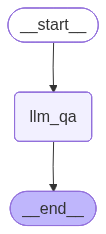

In [74]:
from IPython.display import Image

Image(workflow.get_graph().draw_mermaid_png())